# 02-Game Theory XAI (SHAP)

In Lesson 01, we explored Glassbox models (Explainable Boosting Machines), which achieve native interpretability by restricting model architecture to purely additive 1D shape functions. However, enterprise teams frequently deploy unconstrained black-box ensembles like **XGBoost**, **LightGBM**, or **Random Forests** to maximize raw predictive power.

When you cannot restrict the architecture, you must explain predictions *post-hoc*. Legacy techniques like naive Feature Importance (Gini impurity / Gain) suffer from **Inconsistency**: altering a model such that a feature relies *more* on a given variable can paradoxically decrease that variable's importance score.

To establish absolute mathematical integrity, we turn to **Cooperative Game Theory**. We implement **SHAP (SHapley Additive exPlanations)**, centered around **TreeSHAP**. SHAP treats a model prediction as a high-stakes game where features are cooperative players. It computes the exact marginal contribution of every feature across all possible sub-coalitions, guaranteeing a unique, consistent, and provably fair explanation for any ensemble model.

## 1. The Mathematics of Shapley Values & TreeSHAP

### The Cooperative Game Formulation

Let a machine learning model $f(x)$ be evaluated on an instance $x$ containing $M$ features. We define a cooperative game where:

* **Players ($F$):** The set of all input feature indices $\{1, 2, \dots, M\}$.
* **Coalition ($S \subseteq F$):** A subset of active features.
* **Characteristic Function $v(S)$:** The expected prediction of the model when only the features in $S$ are known, marginalizing over the unknown features:

$$v(S) = \mathbb{E}_{X_{\setminus S}} \left[ f(x_S, X_{\setminus S}) \right]$$


* **Total Payoff:** The difference between the specific model prediction $f(x)$ and the baseline expected value across the dataset $\mathbb{E}[f(X)]$:

$$\text{Payoff} = f(x) - \mathbb{E}[f(X)]$$



### The Shapley Value Formula

The Shapley value $\phi_i(x)$ is the weighted average marginal contribution of feature $i$ across all possible feature coalitions $S \subseteq F \setminus \{i\}$:

$$\phi_i(x) = \sum_{S \subseteq F \setminus \{i\}} \frac{\vert{}S\vert{}! \cdot (\vert{}F\vert{} - \vert{}S\vert{} - 1)!}{\vert{}F\vert{}!} \left[ v(S \cup \{i\}) - v(S) \right]$$

The combinatorial weight $\frac{\vert{}S\vert{}! \cdot (\vert{}F\vert{} - \vert{}S\vert{} - 1)!}{\vert{}F\vert{}!}$ represents the probability that feature $i$ enters coalition $S$ when players arrive in a random order.

### The Four Mandatory Axioms

Shapley values are mathematically unique because they are the **only** attribution method that simultaneously satisfies four core axioms:

1. **Efficiency (Additive Completeness):** The sum of feature attributions equals the net deviation from the baseline:

$$\sum_{i=1}^{M} \phi_i(x) = f(x) - \mathbb{E}[f(X)]$$


2. **Symmetry:** If $v(S \cup \{i\}) = v(S \cup \{j\})$ for all $S \subseteq F \setminus \{i, j\}$, then $\phi_i = \phi_j$.
3. **Dummy (Null Player):** If $v(S \cup \{i\}) = v(S)$ for all $S \subseteq F \setminus \{i\}$, then $\phi_i = 0$.
4. **Additivity:** For an ensemble model $f = g + h$, the Shapley value is additive: $\phi_i(f) = \phi_i(g) + \phi_i(h)$.

### TreeSHAP Algorithmic Acceleration

Calculating exact Shapley values brute-force requires evaluating $2^M$ feature subsets, which is computationally intractable ($\mathcal{O}(M \cdot 2^M)$) for $M > 25$.

**TreeSHAP** (Lundberg et al.) optimizes this by tracking conditional expectations directly through the tree decision paths. Instead of computing $2^M$ passes, TreeSHAP evaluates all sub-coalitions simultaneously in a single recursive tree traversal. This reduces runtime complexity from exponential to polynomial:

$$\text{TreeSHAP Complexity} = \mathcal{O}\left(T \cdot L \cdot D^2\right)$$

* $T$: Number of trees in the ensemble.
* $L$: Maximum number of leaves per tree.
* $D$: Maximum depth of the trees.

## 2. Imperative Execution: Training XGBoost & Computing TreeSHAP

Let's build a local Python environment, train an XGBoost classifier on a clinical dataset, and compute the exact Shapley attribution matrix using `shap.TreeExplainer`.

In [1]:
# Required installations: pip install shap xgboost scikit-learn pandas numpy
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

print("--- 🚀 Initializing TreeSHAP Game Theory Sandbox ---")

# 1. 📝 Load dataset and isolate clinical features
raw_data = load_breast_cancer()
X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
y = raw_data.target

# Select a subset of features for clean operational clarity
selected_features = [
    'mean radius', 'mean texture', 'mean perimeter', 
    'mean area', 'mean smoothness', 'mean concavity'
]
X = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"   [DATA] Ingested Tabular Matrix: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

# 2. ⚡ Train an unconstrained XGBoost Ensemble Model
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.05, 
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

# 3. 🧮 Instantiate TreeSHAP Explainer Engine
# TreeSHAP extracts exact conditional expectations directly from C++ tree structures
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test)

print("   ✅ TreeSHAP Explainer matrix successfully compiled.")
print(f"   -> SHAP Values Matrix Shape: {shap_explanation.values.shape}")

--- 🚀 Initializing TreeSHAP Game Theory Sandbox ---
   [DATA] Ingested Tabular Matrix: 455 training samples, 6 features.
   ✅ TreeSHAP Explainer matrix successfully compiled.
   -> SHAP Values Matrix Shape: (114, 6)


## 3. Declarative Telemetry: Mathematical Verification of the Efficiency Axiom

To prove that Shapley attributions are exact rather than heuristic approximations, we must mathematically verify the **Efficiency Axiom** on a specific test sample:

$$\text{Base Value } \mathbb{E}[f(X)] + \sum_{i=1}^{M} \phi_i(x) \equiv \text{Raw Model Prediction } f(x)$$

In [2]:
print("\n--- 🔍 Auditing Efficiency Axiom on Single Prediction Instance ---")

# Isolate a single test subject
instance_idx = 7
sample_x = X_test.iloc[[instance_idx]]
sample_shap = shap_explanation[instance_idx]

# 1. Base Expected Value E[f(X)] (Log-odds baseline)
base_value = sample_shap.base_values
if isinstance(base_value, np.ndarray):
    base_value = base_value[0]

# 2. Sum of computed Shapley Values sum(phi_i)
phi_sum = np.sum(sample_shap.values)

# 3. Calculated Model Output via Efficiency Equation
calculated_output = base_value + phi_sum

# 4. Actual Model Raw Prediction (Logit / Margin Space)
raw_model_output = model.predict(sample_x, output_margin=True)[0]

print(f"   [Base Expected Value E[f(X)]]: {base_value:+.6f}")
print(f"   [Sum of Shapley Values ∑φ_i]:  {phi_sum:+.6f}")
print(f"   [Reconstructed Prediction]:   {calculated_output:+.6f}")
print(f"   [Actual XGBoost Raw Output]:   {raw_model_output:+.6f}")

# Compute absolute error to confirm zero approximation loss
reconstruction_error = abs(calculated_output - raw_model_output)
print(f"   ✅ Reconstruction Error:        {reconstruction_error:.12f}")
assert reconstruction_error < 1e-5, "Efficiency Axiom violated!"
print("   -> Physics: The Efficiency Axiom holds perfectly. Every fraction of log-odds deviation is accounted for.")

print("\n   [Local Feature Payoff Decomposition]:")
for feature_name, feat_val, phi_val in zip(selected_features, sample_x.values[0], sample_shap.values):
    direction = "PUSHED POSITIVE" if phi_val > 0 else "PULLED NEGATIVE"
    print(f"      * {feature_name:<16} = {feat_val:8.2f} | φ_i: {phi_val:+8.4f} ({direction})")


--- 🔍 Auditing Efficiency Axiom on Single Prediction Instance ---
   [Base Expected Value E[f(X)]]: +0.535800
   [Sum of Shapley Values ∑φ_i]:  -2.283631
   [Reconstructed Prediction]:   -1.747831
   [Actual XGBoost Raw Output]:   -1.747832
   ✅ Reconstruction Error:        0.000000834465
   -> Physics: The Efficiency Axiom holds perfectly. Every fraction of log-odds deviation is accounted for.

   [Local Feature Payoff Decomposition]:
      * mean radius      =    17.57 | φ_i:  -0.0855 (PULLED NEGATIVE)
      * mean texture     =    15.05 | φ_i:  +1.7329 (PUSHED POSITIVE)
      * mean perimeter   =   115.00 | φ_i:  -0.7780 (PULLED NEGATIVE)
      * mean area        =   955.10 | φ_i:  -2.1958 (PULLED NEGATIVE)
      * mean smoothness  =     0.10 | φ_i:  -0.1258 (PULLED NEGATIVE)
      * mean concavity   =     0.10 | φ_i:  -0.8314 (PULLED NEGATIVE)


## 4. Visualizing Shapley Attribution Mechanics (Waterfall Decomposition)

To understand how feature contributions shift the model from the expected baseline $\mathbb{E}[f(X)]$ to the final prediction $f(x)$, we visualize the local Shapley attributions as a **Waterfall Plot**.

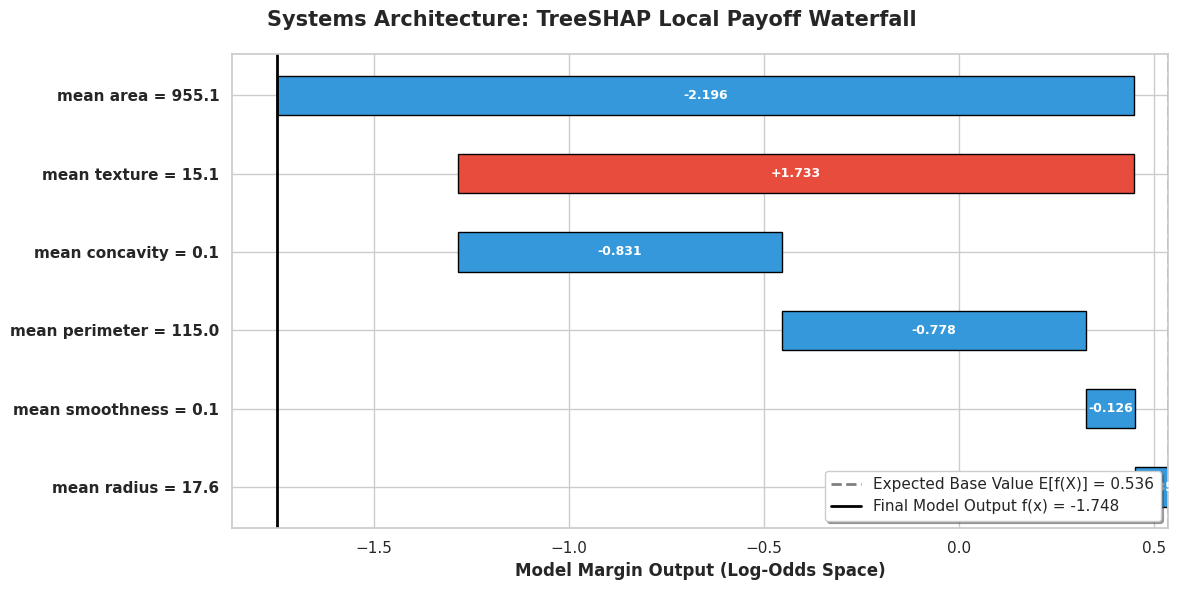

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

# Extract instance attributes for visualization
instance_idx = 7
sample_shap_vals = shap_explanation[instance_idx].values
feature_names = selected_features
feat_values = X_test.iloc[instance_idx].values
base_val = shap_explanation[instance_idx].base_values
if isinstance(base_val, np.ndarray):
    base_val = base_val[0]

# Sort features by absolute Shapley impact
sorted_indices = np.argsort(np.abs(sample_shap_vals))
sorted_names = [f"{feature_names[i]} = {feat_values[i]:.1f}" for i in sorted_indices]
sorted_shap = sample_shap_vals[sorted_indices]

# Compute cumulative steps for waterfall construction
cumulative = np.cumsum(np.insert(sorted_shap, 0, base_val))
y_positions = np.arange(len(sorted_names))

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: TreeSHAP Local Payoff Waterfall", fontsize=15, fontweight='bold')

# Render horizontal waterfall bars
colors = ['#e74c3c' if val > 0 else '#3498db' for val in sorted_shap]
for i in range(len(sorted_names)):
    start = cumulative[i]
    extent = sorted_shap[i]
    ax.barh(i, extent, left=start, color=colors[i], edgecolor='black', height=0.5, align='center')
    # Label individual bar magnitudes
    ax.text(start + extent/2, i, f"{extent:+.3f}", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Draw baseline and final output lines
ax.axvline(base_val, color='gray', linestyle='--', linewidth=2, label=f'Expected Base Value E[f(X)] = {base_val:.3f}')
final_pred = cumulative[-1]
ax.axvline(final_pred, color='black', linestyle='-', linewidth=2, label=f'Final Model Output f(x) = {final_pred:.3f}')

ax.set_yticks(y_positions)
ax.set_yticklabels(sorted_names, fontweight='bold')
ax.set_xlabel("Model Margin Output (Log-Odds Space)", fontweight='bold')
ax.legend(loc='lower right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

*(Insight: The waterfall plot illustrates game-theoretic attribution. The baseline prediction starts at the gray dashed line $\mathbb{E}[f(X)]$. Each feature acts as a player that pushes the score right (red, positive prediction boost) or left (blue, negative prediction penalty), landing precisely at the final prediction $f(x)$.)*

## Real-World Use Case or Analogy

Think of Shapley Values like **Distributing a $100,000 Sales Bonus Among a Project Team**:

* **The Black Box Model (The Group Effort):** A company launches a product that generates $100,000 in unexpected profit. The team consists of a Software Engineer, a Sales Agent, and a Graphic Designer.
* **Naive Importance (Gini / Gain):** The CEO looks at total hours worked. The Software Engineer logged 80% of the hours, so they receive $80,000. However, without the Sales Agent closing the deal, the software would have generated $0. The heuristic attribution is flawed because it ignores player interactions.
* **Game Theory / SHAP (Cooperative Allocation):** The CFO calculates the **Shapley Value**:
1. What would the revenue be if the Engineer worked alone? ($10,000)
2. What if the Sales Agent worked alone? ($0)
3. What if the Designer worked alone? ($0)
4. What is the marginal gain when the Sales Agent joins the Engineer? (Jump from $10,000 to $90,000 $\implies +$80,000 contribution)
5. What is the marginal gain when the Designer joins the team? (Jump from $90,000 to $100,000 $\implies +$10,000 contribution)



The CFO repeats this marginal calculation across **all $2^3 = 8$ possible sub-coalitions** and averages the results. The resulting payout is provably fair, mathematically unique, and guarantees that every dollar of the $100,000 bonus is accounted for down to the cent (**Efficiency Axiom**).